In [1]:
from google.colab import files
uploaded = files.upload()

Saving ml_ready_data.csv to ml_ready_data.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving clean_with_names.csv to clean_with_names.csv


In [15]:
#Question 6
#Determine how many planets have a radius smaller than Earth (pl_rade < 1).
#Identify the top 3 discovery methods responsible for finding these planets.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Astro theme settings
plt.style.use('dark_background')
sns.set_palette("mako")

plt.rcParams['figure.facecolor'] = '#0b0f19'
plt.rcParams['axes.facecolor'] = '#0b0f19'

df = pd.read_csv("clean_with_names.csv")
print("Shape:", df.shape)
df.head()

Shape: (6158, 11)


,pl_name,disc_year,pl_orbper,pl_rade,pl_eqt,st_teff,st_rad,st_mass,sy_dist,disc_facility,disc_method
0,11 Com b,2007.0,324.620000,2.41,805.0,4808.00,16.380000,2.60,93.1846,Xinglong Station,Radial Velocity
1,11 UMi b,2009.0,516.219985,2.41,805.0,4276.50,26.935000,1.80,125.3210,Thueringer Landessternwarte Tautenburg,Radial Velocity
2,14 And b,2008.0,186.300000,2.41,805.0,4850.50,11.275000,1.78,75.4392,Okayama Astrophysical Observatory,Radial Velocity
3,14 Her b,2002.0,1766.410000,2.41,805.0,5297.47,0.995819,0.91,17.9323,W. M. Keck Observatory,Radial Velocity
4,16 Cyg B b,1996.0,799.475000,2.41,805.0,5747.00,1.130000,1.00,21.1397,Multiple Observatories,Radial Velocity


In [27]:
# Filter planets smaller than Earth
small_planets = df[df['pl_rade'] < 1]

# Count
count_small = small_planets.shape[0]
print(f"Total number of planets smaller than Earth: {count_small}")

# Show planet names + radius
small_planet_list = small_planets[['pl_name', 'pl_rade']].sort_values(by='pl_rade')

small_planet_list.head(10)   # show first 10 (clean display)

Total number of planets smaller than Earth: 244


,pl_name,pl_rade
3978,Kepler-37 b,0.296310
3981,Kepler-37 e,0.370000
4129,Kepler-444 b,0.375636
4731,Kepler-879 c,0.400000
2110,KOI-4777.01,0.420000
2932,Kepler-158 d,0.430000
4130,Kepler-444 c,0.468368
3321,Kepler-1877 b,0.480000
2158,Kepler-102 b,0.490000
4132,Kepler-444 e,0.500000


In [28]:
top_methods = small_planets['disc_method'].value_counts().head(3)

print("\n Top 3 Discovery Methods:")
print(top_methods)


 Top 3 Discovery Methods:
disc_method
Transit                          240
Orbital Brightness Modulation      2
Radial Velocity                    1
Name: count, dtype: int64


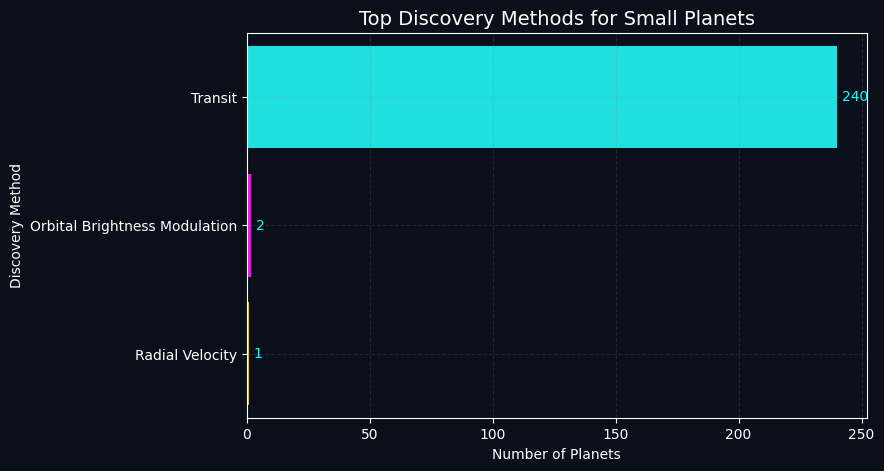

In [22]:
plt.figure(figsize=(8,5))

colors = ["#00FFFF", "#FF00FF", "#FFD700"]

sns.barplot(
    x=top_methods.values,
    y=top_methods.index,
    hue=top_methods.index,
    palette=colors,
    legend=False
)

plt.title("Top Discovery Methods for Small Planets", fontsize=14, color='white')
plt.xlabel("Number of Planets", color='white')
plt.ylabel("Discovery Method", color='white')

for i, v in enumerate(top_methods.values):
    plt.text(v + 2, i, str(v), va='center', color='#00FFFF')

plt.grid(color='gray', linestyle='--', alpha=0.2)
plt.show()

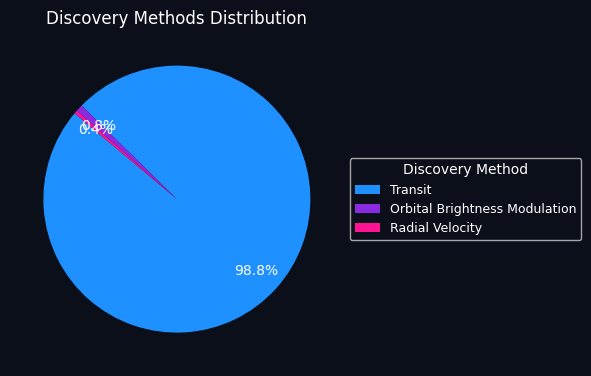

In [26]:
plt.figure(figsize=(6,6))

colors = ["#1E90FF", "#8A2BE2", "#FF1493"]

wedges, texts, autotexts = plt.pie(
    top_methods.values,
    startangle=140,
    colors=colors,
    autopct='%1.1f%%',
    pctdistance=0.8,      # move percentage outward
    labeldistance=1.1,    # move labels outward
    textprops={'color': "white", 'fontsize': 10}
)
for t in texts:
    t.set_text("")

# Add clean legend
plt.legend(
    wedges,
    top_methods.index,
    title="Discovery Method",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=9
)

plt.title("Discovery Methods Distribution", color='white')
plt.tight_layout()
plt.show()

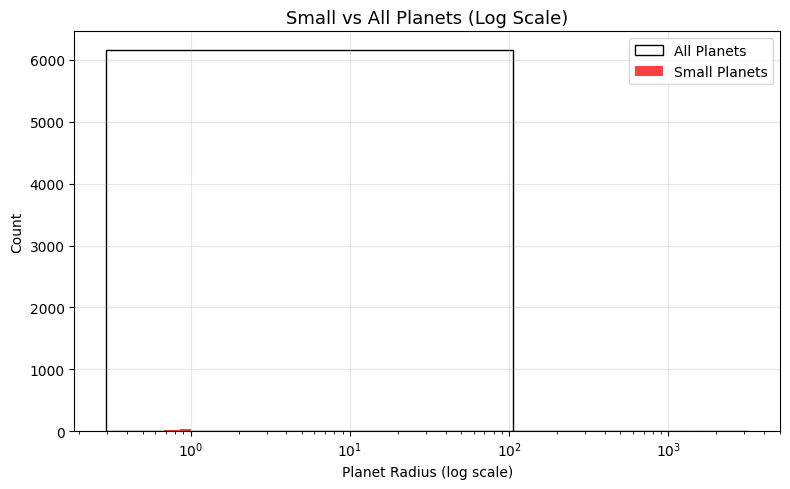

In [47]:
plt.style.use('default')

plt.figure(figsize=(8,5))

sns.histplot(
    df['pl_rade'],
    bins=30,
    color='white',
    label='All Planets',
    alpha=0.5
)

sns.histplot(
    small_planets['pl_rade'],
    bins=20,
    color='red',
    label='Small Planets',
    edgecolor='black'
)

plt.xscale('log')

plt.legend()

plt.title("Small vs All Planets (Log Scale)", fontsize=13, color='black')
plt.xlabel("Planet Radius (log scale)", color='black')
plt.ylabel("Count", color='black')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

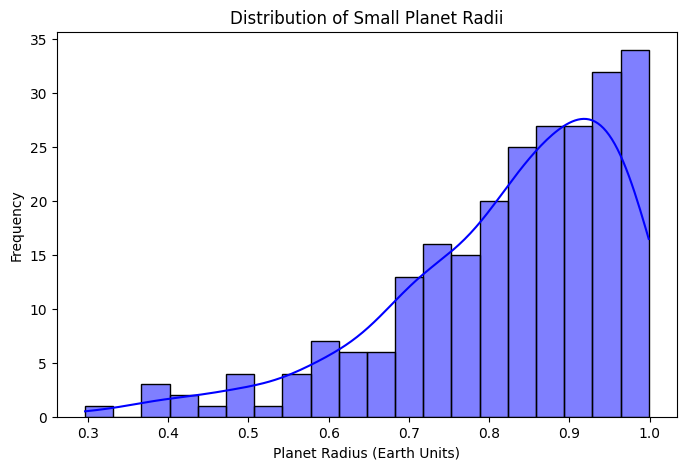

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(small_planets['pl_rade'], bins=20, kde=True, color='blue')

plt.title("Distribution of Small Planet Radii")
plt.xlabel("Planet Radius (Earth Units)")
plt.ylabel("Frequency")

plt.show()
